In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
os.makedirs("model_saved", exist_ok=True)
os.makedirs("figures", exist_ok=True)
print("CELL 1 (Housing): Sẵn sàng.")

CELL 1 (Housing): Sẵn sàng.


In [2]:
df_housing = pd.read_csv("vietnam_housing_dataset.csv")
print("Kích thước dữ liệu giá nhà:", df_housing.shape)
display(df_housing.head(3))

# Kỹ nghệ đặc trưng: Trích xuất tỉnh/thành phố từ Address để tránh bùng nổ chiều
def extract_location(address):
    if pd.isna(address):
        return "Unknown"
    return str(address).split(",")[-1].strip()

df_housing['Location'] = df_housing['Address'].apply(extract_location)
top_locations = df_housing['Location'].value_counts().head(10).index
df_housing['Location'] = df_housing['Location'].where(df_housing['Location'].isin(top_locations), 'Other')

print("\nPhân bố 10 khu vực lớn nhất:")
print(df_housing['Location'].value_counts())

Kích thước dữ liệu giá nhà: (30229, 12)


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.6
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.5
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.9



Phân bố 10 khu vực lớn nhất:
Location
Hồ Chí Minh    11628
Hà Nội          9996
Other           2025
Bình Dương      1655
Đà Nẵng         1411
Đồng Nai         806
Hải Phòng        786
Khánh Hòa        730
Hà Nội.          461
Hưng Yên         403
Long An          328
Name: count, dtype: int64


Thống kê mô tả biến mục tiêu Price (Tỷ VNĐ):
count    30229.000000
mean         5.872078
std          2.211877
min          1.000000
25%          4.200000
50%          5.900000
75%          7.500000
max         11.500000
Name: Price, dtype: float64


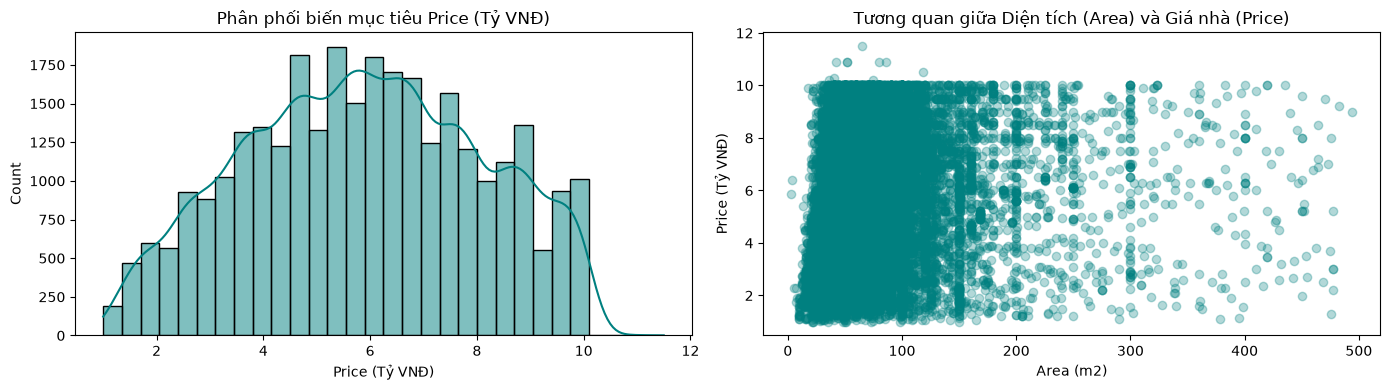

In [3]:
print("Thống kê mô tả biến mục tiêu Price (Tỷ VNĐ):")
print(df_housing['Price'].describe())

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df_housing['Price'], bins=30, kde=True, ax=ax[0], color='teal')
ax[0].set_title("Phân phối biến mục tiêu Price (Tỷ VNĐ)")
ax[0].set_xlabel("Price (Tỷ VNĐ)")

# Lọc Area ngoại lai để trực quan hóa rõ ràng
area_plot_data = df_housing[df_housing['Area'] < 500]
ax[1].scatter(area_plot_data['Area'], area_plot_data['Price'], alpha=0.3, color='teal')
ax[1].set_title("Tương quan giữa Diện tích (Area) và Giá nhà (Price)")
ax[1].set_xlabel("Area (m2)")
ax[1].set_ylabel("Price (Tỷ VNĐ)")
plt.tight_layout()
plt.savefig("figures/fig_3_1_eda_housing.png", dpi=300)
plt.show()

In [4]:
num_features = ['Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms']
cat_features = ['Legal status', 'Furniture state', 'Location']

X = df_housing[num_features + cat_features]
y = df_housing['Price'].values

# Chia 70% Train, 15% Val, 15% Test
X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_features)
])

# Fit CHỈ trên train
X_train = preprocessor.fit_transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)
X_test = preprocessor.transform(X_test_raw)

# Chuẩn hóa Z-score biến mục tiêu Price để chống bùng nổ Gradient khi train Deep Learning
y_mean = y_train_raw.mean()
y_std = y_train_raw.std()

y_train_s = (y_train_raw - y_mean) / y_std
y_val_s = (y_val_raw - y_mean) / y_std

print("Số chiều đặc trưng sau mã hóa:", X_train.shape[1])
print(f"Train size: {X_train.shape[0]} | Val size: {X_val.shape[0]} | Test size: {X_test.shape[0]}")

Số chiều đặc trưng sau mã hóa: 23
Train size: 21160 | Val size: 4534 | Test size: 4535


In [5]:
baseline_regressors = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Reg.": DecisionTreeRegressor(max_depth=10, random_state=SEED),
    "Random Forest Reg.": RandomForestRegressor(n_estimators=100, max_depth=12, random_state=SEED, n_jobs=-1)
}

reg_results = []
for name, model in baseline_regressors.items():
    model.fit(X_train, y_train_raw)
    preds = model.predict(X_test)
    reg_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test_raw, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test_raw, preds)),
        "R2": r2_score(y_test_raw, preds)
    })

df_reg_results = pd.DataFrame(reg_results)
print("BẢNG ĐỐI SÁNH CÁC MÔ HÌNH HỒI QUY CƠ BẢN:")
display(df_reg_results)

BẢNG ĐỐI SÁNH CÁC MÔ HÌNH HỒI QUY CƠ BẢN:


,Model,MAE,RMSE,R2
0,Linear Regression,1.451886,1.817262,0.310103
1,Decision Tree Reg.,1.301230,1.688058,0.404717
2,Random Forest Reg.,1.236921,1.588410,0.472923


In [6]:
# Kiến trúc 5 tầng: Input(d) -> 128 -> 64 -> 32 -> 16 -> Output(1, Linear)
class HousePriceMLP5(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1) # Output liên tục
        )
    def forward(self, x):
        return self.net(x)

in_dim = X_train.shape[1]
house_model = HousePriceMLP5(in_features=in_dim)
print(house_model)
print(f"\nTổng tham số mạng hồi quy 5 tầng: {sum(p.numel() for p in house_model.parameters()):,}")

HousePriceMLP5(
  (net): Sequential(
    (0): Linear(in_features=23, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)

Tổng tham số mạng hồi quy 5 tầng: 13,953


In [7]:
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), 
                              torch.tensor(y_train_s, dtype=torch.float32).unsqueeze(1))
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

criterion_mse = nn.MSELoss()
optimizer_house = optim.Adam(house_model.parameters(), lr=0.001)

history_house = {'train_loss': [], 'val_loss': []}
epochs_house = 40

for epoch in range(1, epochs_house + 1):
    house_model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer_house.zero_grad()
        preds = house_model(xb)
        loss = criterion_mse(preds, yb)
        loss.backward()
        optimizer_house.step()
        running_loss += loss.item() * len(yb)
        
    house_model.eval()
    with torch.no_grad():
        val_preds_s = house_model(torch.tensor(X_val, dtype=torch.float32))
        v_loss = criterion_mse(val_preds_s, torch.tensor(y_val_s, dtype=torch.float32).unsqueeze(1)).item()
        
    history_house['train_loss'].append(running_loss / len(X_train))
    history_house['val_loss'].append(v_loss)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:02d}/{epochs_house} | Train MSE: {history_house['train_loss'][-1]:.4f} | Val MSE: {v_loss:.4f}")

Epoch 10/40 | Train MSE: 0.5125 | Val MSE: 0.5464
Epoch 20/40 | Train MSE: 0.4864 | Val MSE: 0.5493
Epoch 30/40 | Train MSE: 0.4642 | Val MSE: 0.5556
Epoch 40/40 | Train MSE: 0.4434 | Val MSE: 0.5676


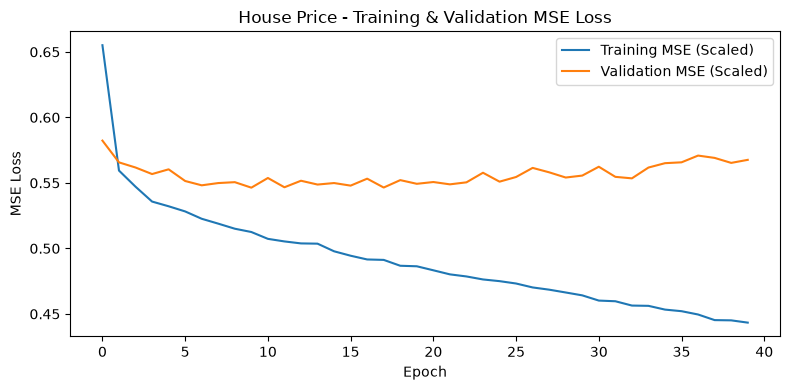

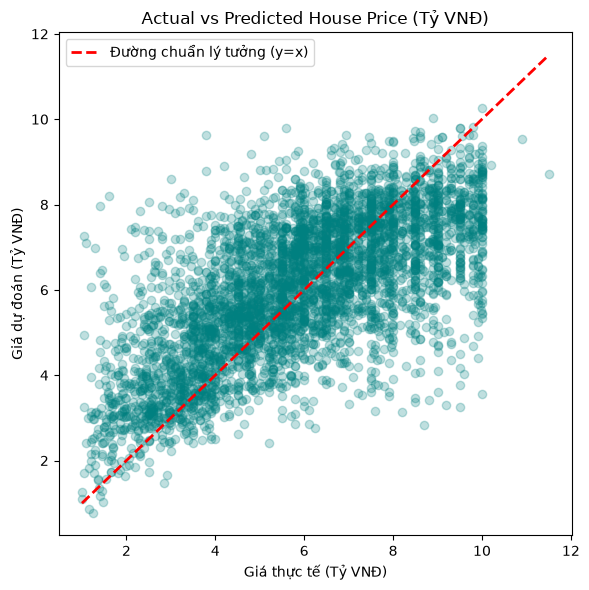

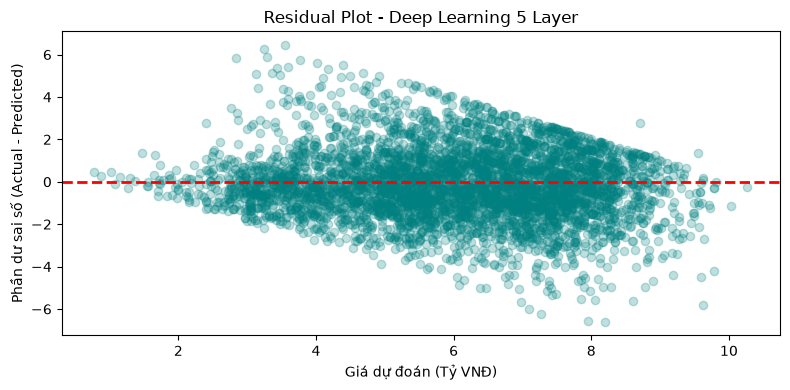


BẢNG ĐỐI SÁNH HIỆU NĂNG HỒI QUY TOÀN DIỆN (TEST SET):


,Model,MAE,RMSE,R2
0,Linear Regression,1.451886,1.817262,0.310103
1,Decision Tree Reg.,1.301230,1.688058,0.404717
2,Random Forest Reg.,1.236921,1.588410,0.472923
3,Deep Learning 5-Layer,1.268468,1.631874,0.443683


CELL 8 (Housing): Đã lưu trữ hoàn tất.


In [8]:
# Biến đổi ngược về đơn vị thực (Tỷ VNĐ): y = y_s * std + mean
house_model.eval()
with torch.no_grad():
    test_preds_s = house_model(torch.tensor(X_test, dtype=torch.float32)).numpy().ravel()
    test_preds = test_preds_s * y_std + y_mean

# 1. Đường cong Learning Curves
plt.figure(figsize=(8, 4))
plt.plot(history_house['train_loss'], label='Training MSE (Scaled)')
plt.plot(history_house['val_loss'], label='Validation MSE (Scaled)')
plt.title("House Price - Training & Validation MSE Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.savefig("figures/fig_3_7_learning_curves_housing.png", dpi=300)
plt.show()

# 2. Biểu đồ Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test_raw, test_preds, alpha=0.25, color='teal')
plt.plot([y_test_raw.min(), y_test_raw.max()], [y_test_raw.min(), y_test_raw.max()], 'r--', lw=2, label='Đường chuẩn lý tưởng (y=x)')
plt.title("Actual vs Predicted House Price (Tỷ VNĐ)")
plt.xlabel("Giá thực tế (Tỷ VNĐ)")
plt.ylabel("Giá dự đoán (Tỷ VNĐ)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/fig_3_8_actual_vs_predicted_housing.png", dpi=300)
plt.show()

# 3. Biểu đồ Residual Plot
residuals = y_test_raw - test_preds
plt.figure(figsize=(8, 4))
plt.scatter(test_preds, residuals, alpha=0.25, color='teal')
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.title("Residual Plot - Deep Learning 5 Layer")
plt.xlabel("Giá dự đoán (Tỷ VNĐ)")
plt.ylabel("Phần dư sai số (Actual - Predicted)")
plt.tight_layout()
plt.savefig("figures/fig_3_9_residuals_housing.png", dpi=300)
plt.show()

# Bảng so sánh tổng hợp
dl_house_res = {
    "Model": "Deep Learning 5-Layer",
    "MAE": mean_absolute_error(y_test_raw, test_preds),
    "RMSE": np.sqrt(mean_squared_error(y_test_raw, test_preds)),
    "R2": r2_score(y_test_raw, test_preds)
}
final_housing_comparison = pd.concat([df_reg_results, pd.DataFrame([dl_house_res])], ignore_index=True)
print("\nBẢNG ĐỐI SÁNH HIỆU NĂNG HỒI QUY TOÀN DIỆN (TEST SET):")
display(final_housing_comparison)

# Lưu trữ artifacts
joblib.dump(preprocessor, "model_saved/housing_preprocessor.joblib")
joblib.dump({'mean': y_mean, 'std': y_std}, "model_saved/housing_target_scaler.joblib")
torch.save(house_model.state_dict(), "model_saved/housing_mlp5.pth")
print("CELL 8 (Housing): Đã lưu trữ hoàn tất.")